In [2]:
# Data import
from sklearn.datasets import fetch_openml

# Data handling
import numpy as np
import pandas as pd
import sklearn
from collections import Counter

# Feature pre-processing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Model and training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier

#Validation
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
#Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
print(sklearn.__version__)


1.8.0


Unique values instances per feature
 X1       9822
X2       9826
X3       9625
X4       9810
X5       9840
X6       9703
X7       9816
X8       9810
X9       9595
X10      9817
X11      9827
X12      9664
X13      9466
X14      9489
X15      8395
X16      9557
X17      9584
X18      8724
X19      9425
X20      9380
X21      8304
X22      9473
X23      9533
X24      8714
X25      9831
X26      9844
X27      9824
X28      9827
X29      9509
X30      9635
X31      9493
X32      9576
phase       5
dtype: int64


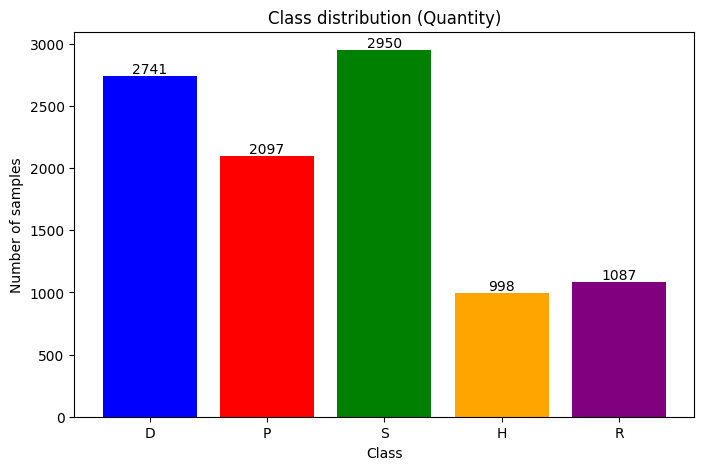

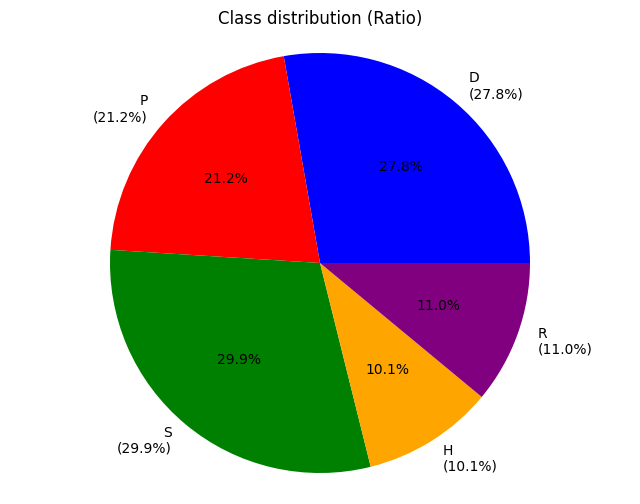

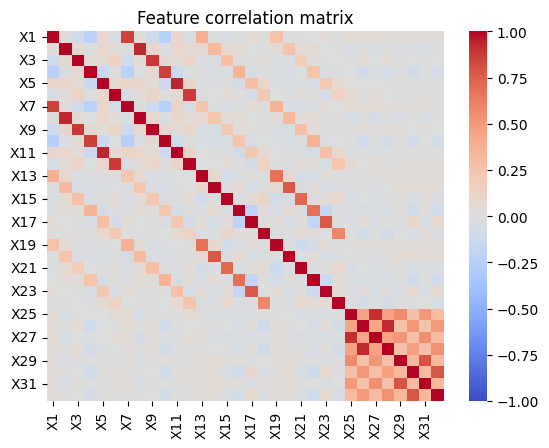

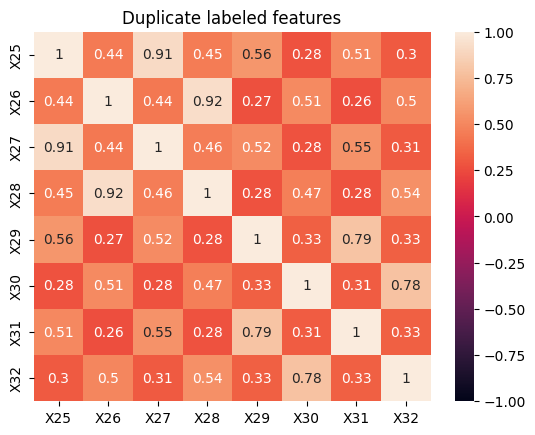

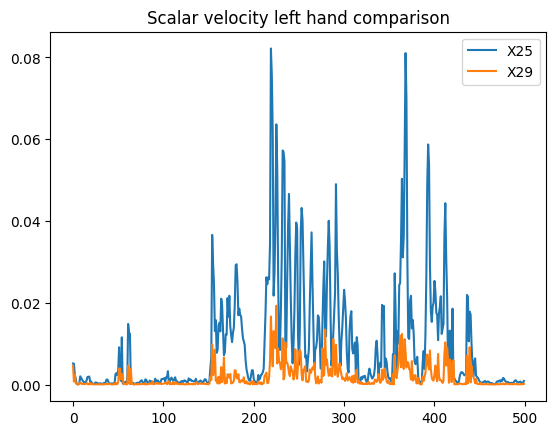

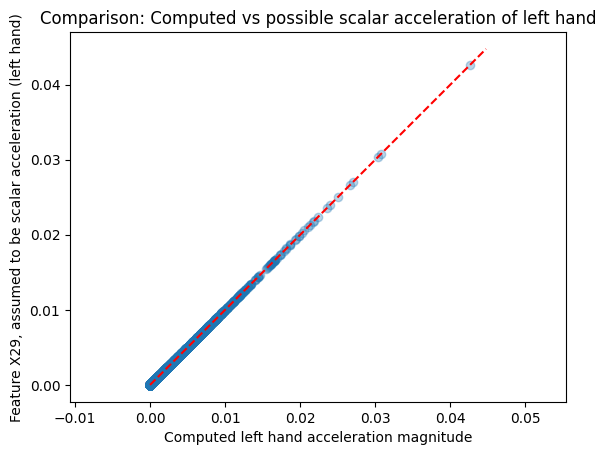

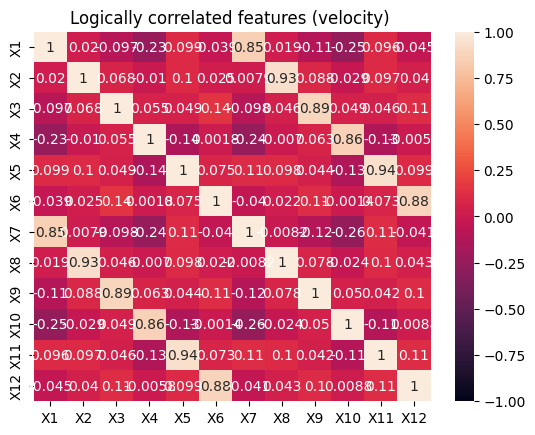

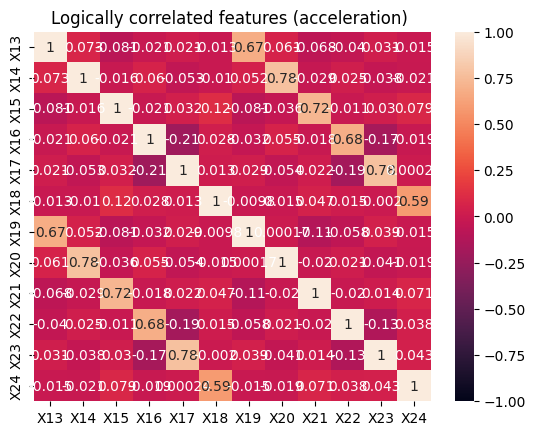

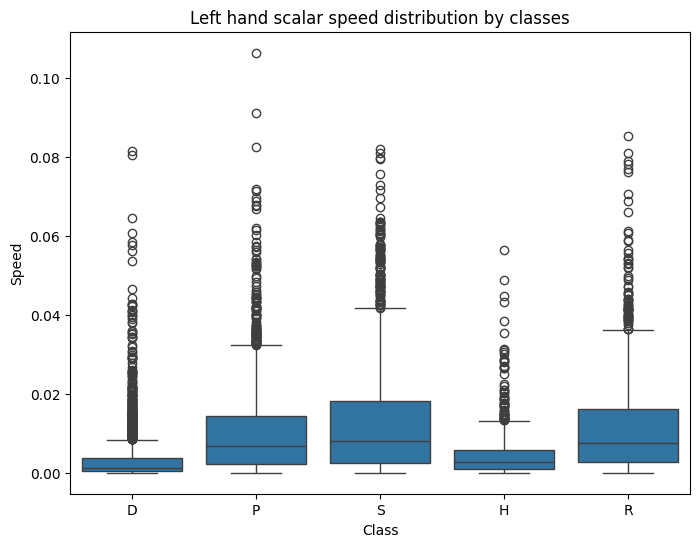

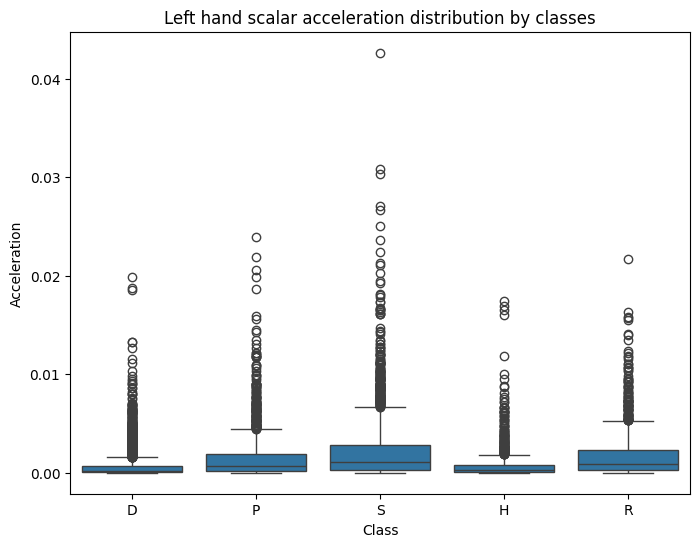

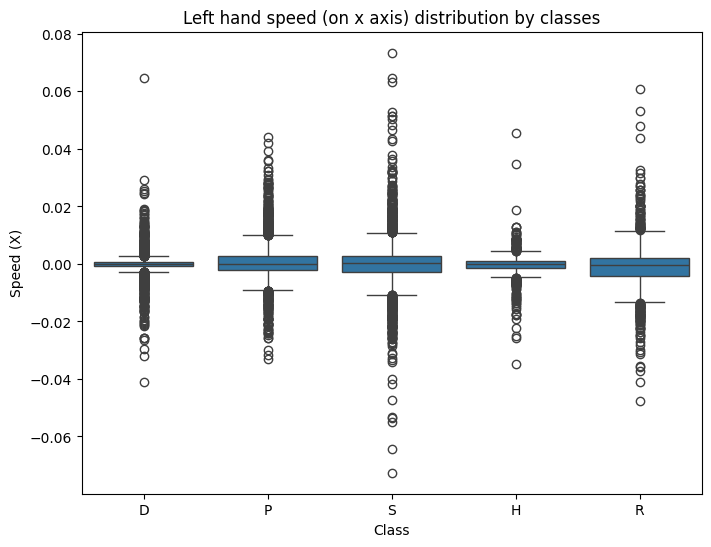

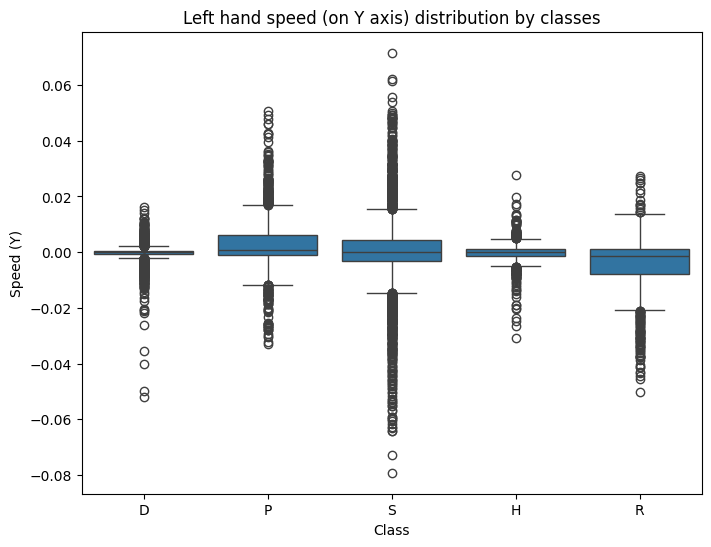

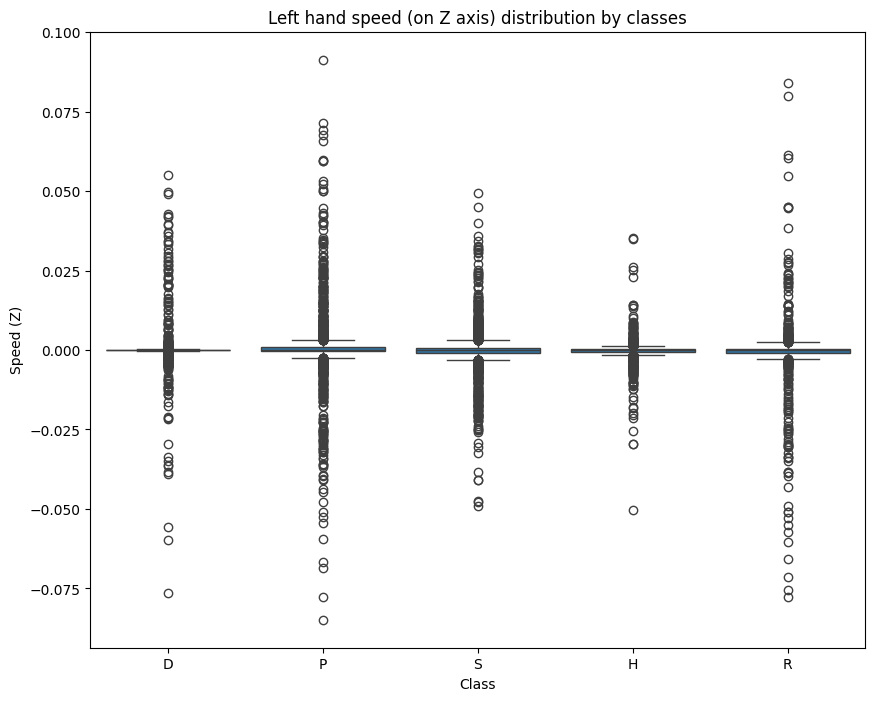

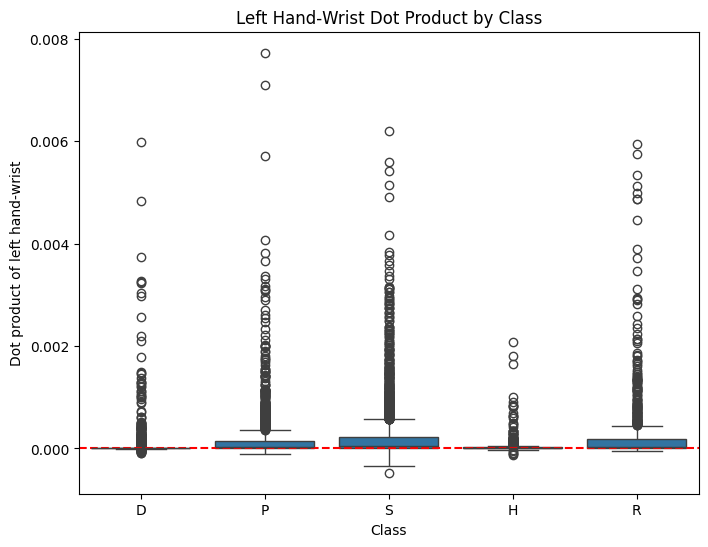

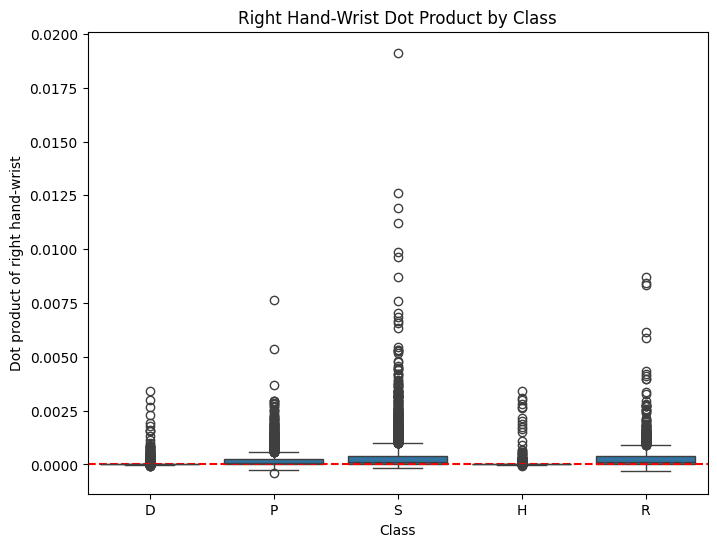

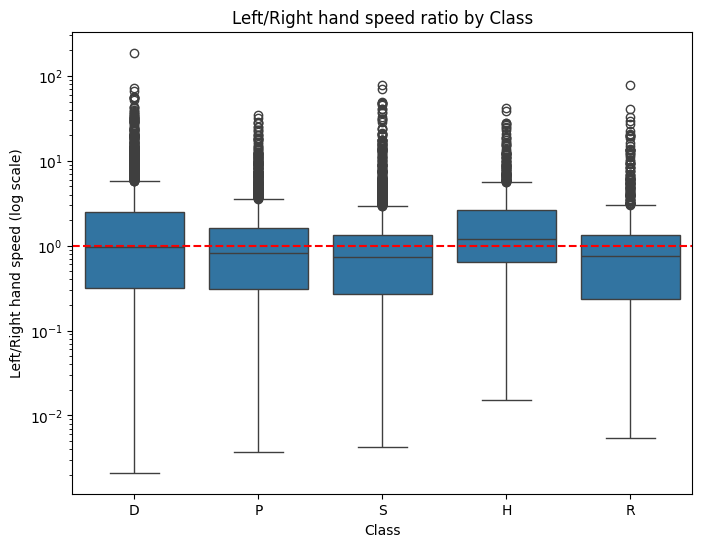

In [4]:
#Loading data
dataset = fetch_openml(data_id=4538, as_frame=False)
X = dataset.data.astype(float)
y = dataset.target

#dataframe for visualisation
df = pd.DataFrame(X, columns=dataset.feature_names)
df['phase'] = y

#Visualising data--------------------------
print("Unique values instances per feature\n", df.nunique()) 


#Class balance observation---------------
class_counts = Counter(y)
classes = ['D', 'P', 'S', 'H', 'R']
counts = [class_counts.get(c, 0) for c in classes]

#Quantity comparison (bar)
plt.figure(figsize=(8,5))
plt.bar(classes, counts,  color=['blue', 'red', 'green', 'orange', 'purple'])
plt.title('Class distribution (Quantity)')
plt.xlabel('Class')
plt.ylabel('Number of samples')
for i, v in enumerate(counts):
    plt.text(i, v + 20, str(v), ha='center')
plt.show()

#Ratio comparison (pie)
total = sum(counts)
percentages = [count/total*100 for count in counts]
labels  = [f'{c}\n({p:.1f}%)' for c, p in zip(classes, percentages)]
plt.figure(figsize=(8,6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['blue', 'red', 'green', 'orange', 'purple'])
plt.title('Class distribution (Ratio)')
plt.axis('equal')
plt.show()
#-----------------------



#Overarching feature anaylsis-------------
#Correlation matrix
corr_matrix = df.iloc[:, :-1].astype(float).corr()
sns.heatmap(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature correlation matrix")
plt.show()

#Duplicate label correlation matrix
duplicate_set = df.iloc[:, 24:32].astype(float)
corr_duplicates = duplicate_set.corr()
sns.heatmap(corr_duplicates, annot=True, vmin =-1, vmax=1)
plt.title("Duplicate labeled features")
plt.show()

#Duplicate feature comparison
plt.plot(df['X25'].iloc[:500], label ='X25')
plt.plot(df['X29'].iloc[:500], label ='X29')
plt.legend()
plt.title("Scalar velocity left hand comparison")
plt.show()

left_acc_mag = np.sqrt(df['X13']**2 +  df['X14']**2 + df['X15']**2)
plt.scatter(left_acc_mag, df['X29'], alpha=0.3)
plt.xlabel('Computed left hand acceleration magnitude')
plt.ylabel('Feature X29, assumed to be scalar acceleration (left hand)')
plt.title('Comparison: Computed vs possible scalar acceleration of left hand')
plt.plot([0, plt.xlim()[1]], [0, plt.xlim()[1]], 'r--')
plt.axis('equal')
plt.show()


#Logical correlation matrix (Velocity)
velocity_set = df.iloc[:, 0:12].astype(float)
corr_velocity = velocity_set.corr()
sns.heatmap(corr_velocity, annot=True, vmin =-1, vmax=1)
plt.title("Logically correlated features (velocity) ")
plt.show()

#Logical correlation matrix (Acceleration)
acceleration_set = df.iloc[:, 12:24].astype(float)
corr_acceleration = acceleration_set.corr()
sns.heatmap(corr_acceleration, annot=True, vmin =-1, vmax=1)
plt.title("Logically correlated features (acceleration) ")
plt.show()
#--------------------------------

#Scalar analysis
#Velocity
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='phase', y = 'X25')
plt.ylabel('Speed')
plt.xlabel('Class')
plt.title('Left hand scalar speed distribution by classes')
plt.show()

#Acceleration
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='phase', y = 'X29')
plt.ylabel('Acceleration')
plt.xlabel('Class')
plt.title('Left hand scalar acceleration distribution by classes')
plt.show()
#-------------------



#Velocity direction analysis-----------------
#X
plt.figure(figsize=(8,6))
sns.boxplot(data=df,  x='phase', y='X1')
plt.ylabel('Speed (X)')
plt.xlabel('Class')
plt.title('Left hand speed (on x axis) distribution by classes')
plt.show()

#Y
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='phase', y='X2')
plt.ylabel('Speed (Y)')
plt.xlabel('Class')
plt.title('Left hand speed (on Y axis) distribution by classes')
plt.show()

#Z
plt.figure(figsize=(10,8))
sns.boxplot(data=df, x='phase', y='X3')
plt.ylabel('Speed (Z)')
plt.xlabel('Class')
plt.title('Left hand speed (on Z axis) distribution by classes')
plt.show()

#-----------------------------------------------

#Hand-Wrist alignment analysis------
left_dot = (df['X1'] * df['X7']+
            df['X2'] * df['X8']+
            df['X3'] * df['X9'])

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='phase', y=left_dot)
plt.title('Left Hand‑Wrist Dot Product by Class')
plt.ylabel('Dot product of left hand-wrist')
plt.xlabel('Class')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

right_dot = (df['X4'] * df['X10']+
            df['X5'] * df['X11']+
            df['X6'] * df['X12'])

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='phase', y=right_dot)
plt.title('Right Hand‑Wrist Dot Product by Class')
plt.ylabel('Dot product of right hand-wrist')
plt.xlabel('Class')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()
#------------------------------------

#Left-Right velocity ratio----------------
epsilon = 1e-8
left_right_vel_ratio = df['X25'] / (df['X26'] + epsilon)

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='phase', y=left_right_vel_ratio)
plt.yscale('log')
plt.title('Left/Right hand speed ratio by Class')
plt.ylabel('Left/Right hand speed (log scale)')
plt.xlabel('Class')
plt.axhline(y=1, color='red', linestyle='--')
plt.show()

#-----------------------------------------

Training set shape = (6911, 32)
Test set shape = (2962, 32)
Counter({'S': 2065, 'D': 1919, 'P': 1468, 'R': 761, 'H': 698})
Counter({'S': 885, 'D': 822, 'P': 629, 'R': 326, 'H': 300})
PCA results => (20, 32)
Variance ratio =>
 [0.13406234 0.09512721 0.08200879 0.07713089 0.06910493 0.06327387
 0.05956676 0.05156825 0.04715807 0.04517631 0.03973526 0.0375281
 0.03233905 0.03029897 0.02652673 0.01816501 0.01408145 0.01230116
 0.01058476 0.00899126]


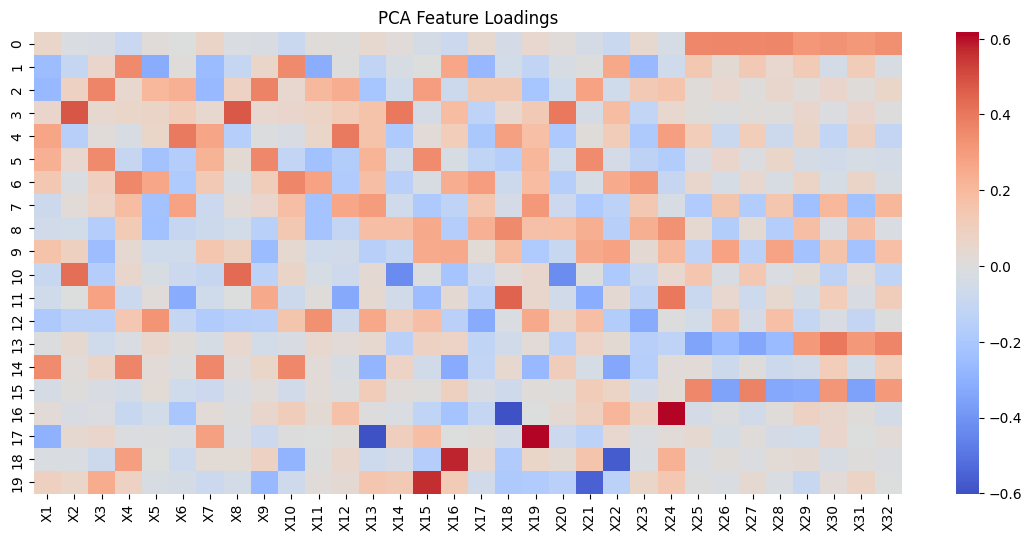

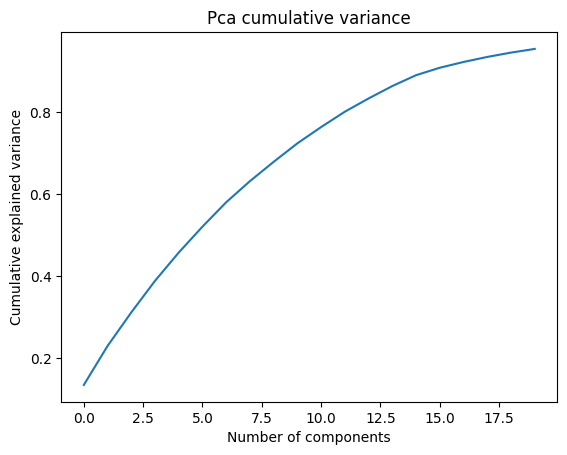

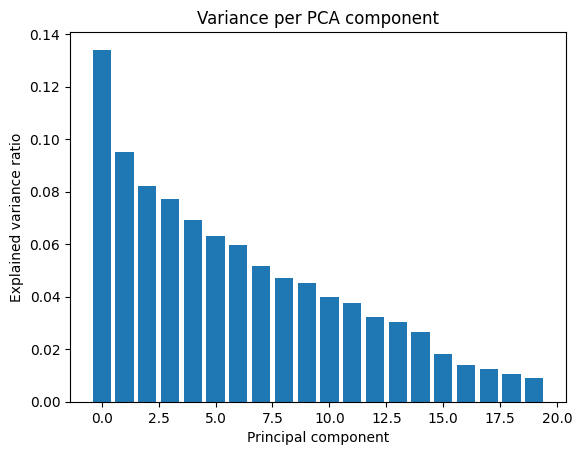

In [ ]:
#Data splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
print("Training set shape =", X_train.shape)
print("Test set shape =", X_test.shape)

#Processing data (Scaling 0-1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Optimising (PCA)----------
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("PCA results =>", pca.components_.shape)
print("Variance ratio =>\n", pca.explained_variance_ratio_)

#Loadings matrix
loadings = pd.DataFrame(
    pca.components_,
    columns=dataset.feature_names
)
plt.figure(figsize=(14, 6))
sns.heatmap(loadings, cmap="coolwarm", center=0)
plt.title("PCA Feature Loadings")
plt.show()

#Variance graphs
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Pca cumulative variance")
plt.show()

plt.bar(range(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Variance per PCA component")
plt.show()
#--------------------------

In [ ]:
#Model training

#Logistic regression (PCA)--------------------------
logcsf_pca = LogisticRegression(
    max_iter=10000, solver='lbfgs', class_weight='balanced')
logcsf_pca.fit(X_train_pca, y_train)
y_logpred_pca = logcsf_pca.predict(X_test_pca)

#--------------------------------------

#logistric regression (NO PCA)----------------
logcsf = LogisticRegression(max_iter=10000, solver='lbfgs', class_weight='balanced')
logcsf.fit(X_train_scaled, y_train)

y_logpred = logcsf.predict(X_test_scaled)
#------------------------------------

#Support vector machine------------------
svm = SVC(kernel='rbf',
          C=10,
          gamma=0.1,
          decision_function_shape='ovr',
          class_weight='balanced',
          probability=False
         )
svm.fit(X_train_scaled, y_train)
y_svmpred = svm.predict(X_test_scaled)
#-------------------------------------

#Random forest with GridSearch----------------------
rf = RandomForestClassifier(
    random_state=42, 
    class_weight='balanced', 
    max_depth=20, 
    max_features='sqrt', 
    min_samples_leaf=2, 
    min_samples_split=5, 
    n_estimators=700,
    n_jobs=-1
    )

rf.fit(X_train_scaled, y_train)
y_rfpred = rf.predict(X_test_scaled)
#-------------------------------------------------


In [7]:
#Extra trees forest -------------------------------------
etc = ExtraTreesClassifier(random_state=42, n_jobs=-1)
etc_param_grid = {
    'n_estimators': [300, 500, 700, 1000],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1,2,4],
    'max_features': ['sqrt', 'log2', 0.5],
    'class_weight': ['balanced']
}

randomsearch_et = RandomizedSearchCV(
    estimator=etc,
    param_distributions=etc_param_grid,
    n_iter=60,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

randomsearch_et.fit(X_train_scaled, y_train)
y_etpred  = randomsearch_et.predict(X_test_scaled)
print("Extra trees classifier best params:", randomsearch_et.best_params_)
print("Extra trees accuracy score:", accuracy_score(y_test, y_etpred))
print("Extra trees classification report\n", classification_report(y_test, y_etpred))
#-----------------

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Extra trees classifier best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None, 'class_weight': 'balanced'}
Extra trees accuracy score: 0.7062795408507765
Extra trees classification report
               precision    recall  f1-score   support

           D       0.71      0.89      0.79       822
           H       0.85      0.52      0.64       300
           P       0.70      0.54      0.61       629
           R       0.69      0.55      0.61       326
           S       0.68      0.78      0.73       885

    accuracy                           0.71      2962
   macro avg       0.73      0.65      0.68      2962
weighted avg       0.71      0.71      0.70      2962



In [16]:
#Gradient boosting-----------------------------------------
hgb = HistGradientBoostingClassifier(random_state=42)
hgb_param_dist = {
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'max_depth': [4, 6, 8, None],
    'max_iter': [150, 200, 300],
    'min_samples_leaf': [20, 40, 80],
    'l2_regularization': [0.0, 0.1, 0.5, 1.0],
    'max_bins': [255]
}

hgb_randomsearch_cv = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=hgb_param_dist,
    n_iter=60,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

hgb_randomsearch_cv.fit(X_train, y_train)
y_hgbpred  = hgb_randomsearch_cv.predict(X_test)
print("Gradient boosting classifier best params:", hgb_randomsearch_cv.best_params_)
print("Gradient boosting accuracy score:", accuracy_score(y_test, y_hgbpred))
print("Gradient boosting classification report\n", classification_report(y_test, y_hgbpred))
#-------------------------------------------------------

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Gradient boosting classifier best params: {'min_samples_leaf': 40, 'max_iter': 200, 'max_depth': None, 'max_bins': 255, 'learning_rate': 0.1, 'l2_regularization': 1.0}
Gradient boosting accuracy score: 0.6789331532748143
Gradient boosting classification report
               precision    recall  f1-score   support

           D       0.72      0.85      0.78       822
           H       0.68      0.47      0.55       300
           P       0.63      0.56      0.60       629
           R       0.65      0.48      0.55       326
           S       0.67      0.75      0.71       885

    accuracy                           0.68      2962
   macro avg       0.67      0.62      0.64      2962
weighted avg       0.68      0.68      0.67      2962



In [ ]:
lgbm = LGBMClassifier(random_state=42, n_jobs=-1)

lgbm_param_dist = {
    'num_leaves': [31, 50, 70],
    'max_depth': [4, 6, 8, None],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'n_estimators': [150, 200, 300],
    'min_child_samples': [20, 40, 60],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'reg_alpha': [0.0, 0.1, 0.5],
    'reg_lambda': [0.0, 0.1, 0.5],
    'class_weight': ['balanced']
}

lgbm_random_search_cv = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_param_dist,
    n_iter=60,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

lgbm_random_search_cv.fit(X_train, y_train)
y_lgbmpred =  lgbm_random_search_cv.predict(X_test)

print("LightGBM best params:", lgbm_random_search_cv.best_params_)
print("LightGBM accuracy:", accuracy_score(y_test, y_lgbmpred))
print("LightGBM classification report:\n", classification_report(y_test, y_lgbmpred))

Fitting 3 folds for each of 60 candidates, totalling 180 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000879 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8160
[LightGBM] [Info] Number of data points in the train set: 6911, number of used features: 32
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
LightGBM best params: {'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'num_leaves': 50, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': None, 'learning_rate': 0.08, 'colsample_bytree': 1.0, 'class_weight': 'balanced'}
LightGBM accuracy: 0.7002025658338961
LightGBM classification report:
               precision    recall  f1-score   support

           D     

c:\Users\me\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [4]:
pipeline_smote_lgbm = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgbm', LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        objective='multiclass'
    ))
])

param_dist_smote_lgbm = {
    'smote__k_neighbors': [3, 5, 7],
    'lgbm__num_leaves': [31, 50, 70],
    'lgbm__max_depth': [4, 6, 8, None],
    'lgbm__learning_rate': [0.03, 0.05, 0.08, 0.1],
    'lgbm__n_estimators': [150, 200, 300],
    'lgbm__min_child_samples': [20, 40, 60],
    'lgbm__subsample': [0.7, 0.85, 1.0],
    'lgbm__colsample_bytree': [0.6, 0.8, 1.0],
    'lgbm__reg_alpha': [0.0, 0.1, 0.5],
    'lgbm__reg_lambda': [0.0, 0.1, 0.5]
}

smote_lgbm_search = RandomizedSearchCV(
    estimator=pipeline_smote_lgbm,
    param_distributions=param_dist_smote_lgbm,
    n_iter=60,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1
)

smote_lgbm_search.fit(X_train, y_train)
Y_lgbm_smote_pred = smote_lgbm_search.predict(X_test)

print("LGBM + SMOTE accuracy score =", accuracy_score(y_test, Y_lgbm_smote_pred))
print("LGBM + SMOTE classification report =", classification_report(y_test, Y_lgbm_smote_pred))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8160
[LightGBM] [Info] Number of data points in the train set: 10325, number of used features: 32
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
LGBM + SMOTE accuracy score = 0.699189736664416
LGBM + SMOTE classification report =               precision    recall  f1-score   support

           D       0.75      0.84      0.80       822
           H       0.63      0.58      0.60       300
           P       0.68      0.58      0.63       629
           R       0.59      0.62      0.61       326
           S       0.72      0.72      0.72       885

    accuracy                  

c:\Users\me\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [6]:
print("LGBM + SMOTE best parameters =", smote_lgbm_search.best_params_)

LGBM + SMOTE best parameters = {'smote__k_neighbors': 5, 'lgbm__subsample': 0.7, 'lgbm__reg_lambda': 0.1, 'lgbm__reg_alpha': 0.0, 'lgbm__num_leaves': 70, 'lgbm__n_estimators': 150, 'lgbm__min_child_samples': 20, 'lgbm__max_depth': None, 'lgbm__learning_rate': 0.1, 'lgbm__colsample_bytree': 0.8}


In [10]:
pipeline_et  = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('et', ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

et_smote_param_dist = {
    'smote__k_neighbors': [6, 7, 8, 9],
    'et__n_estimators': [300, 400, 500],
    'et__max_depth': [35, 40, 45,],
    'et__min_samples_split': [3, 5, 6],
    'et__min_samples_leaf': [1, 2],
    'et__max_features': [0.7, 0.8, 0.9],
    'et__bootstrap': [False],
    'et__class_weight': ['balanced']
}

et_smote_random_search = RandomizedSearchCV(
    estimator=pipeline_et,
    param_distributions=et_smote_param_dist,
    n_iter=60,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

et_smote_random_search.fit(X_train, y_train)
y_et_smote_pred = et_smote_random_search.predict(X_test)

print("Extra trees + smote best params =", et_smote_random_search.best_params_)
print("Extra trees + smote best score =", accuracy_score(y_test, y_et_smote_pred))
print("Extra trees + smote best score =", classification_report(y_test, y_et_smote_pred))


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Extra trees + smote best params = {'smote__k_neighbors': 9, 'et__n_estimators': 300, 'et__min_samples_split': 3, 'et__min_samples_leaf': 1, 'et__max_features': 0.8, 'et__max_depth': 45, 'et__class_weight': 'balanced', 'et__bootstrap': False}
Extra trees + smote best score = 0.7096556380823767
Extra trees + smote best score =               precision    recall  f1-score   support

           D       0.74      0.86      0.80       822
           H       0.68      0.62      0.64       300
           P       0.71      0.56      0.62       629
           R       0.62      0.65      0.63       326
           S       0.72      0.74      0.73       885

    accuracy                           0.71      2962
   macro avg       0.69      0.68      0.69      2962
weighted avg       0.71      0.71      0.71      2962



In [ ]:
#Cached model validation, DONOT RUN
#SMV validation--------------------
smv_cv = SVC(kernel='rbf', class_weight='balanced')

smv_param_grid ={
    'C' : [5, 10, 20],
    'gamma': [0.05, 0.1, 0.2],
    'class_weight': ['balanced']
}

grid_svm = GridSearchCV(
    estimator=smv_cv,
    param_grid=smv_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train_scaled,  y_train)
y_smvpred_cv = grid_svm.predict(X_test_scaled)

#Support vector machine best parameters found: {'C': 10, 'class_weight': 'balanced', 'gamma': 0.1}
#---------------------------

#Random forest validation--------------------------
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_param_grid = {
    'n_estimators': [700, 850, 1000],
    'max_depth': [20,25,30, None],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2,3],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train_scaled, y_train)
y_rfpred = grid_rf.predict(X_test_scaled)

#Random forest best parameters found: {'class_weight': 'balanced', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 700}
#----------------------------------------------

Logistic regression with PCA accuracy score = 0.43889264010803514
Logistic regression with PCA classification report 
               precision    recall  f1-score   support

           D       0.52      0.72      0.60       822
           H       0.18      0.25      0.21       300
           P       0.44      0.41      0.42       629
           R       0.36      0.48      0.41       326
           S       0.58      0.25      0.35       885

    accuracy                           0.44      2962
   macro avg       0.41      0.42      0.40      2962
weighted avg       0.47      0.44      0.43      2962



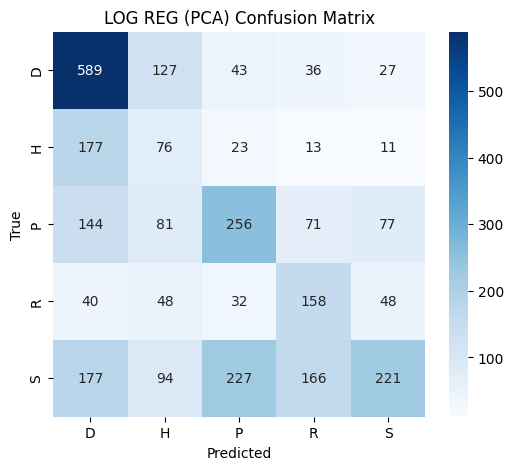

Logistic regression accuracy score = 0.4415935178933153
Logistic regression classification report 
               precision    recall  f1-score   support

           D       0.52      0.68      0.59       822
           H       0.22      0.36      0.27       300
           P       0.44      0.40      0.42       629
           R       0.36      0.50      0.42       326
           S       0.59      0.25      0.35       885

    accuracy                           0.44      2962
   macro avg       0.43      0.44      0.41      2962
weighted avg       0.48      0.44      0.43      2962



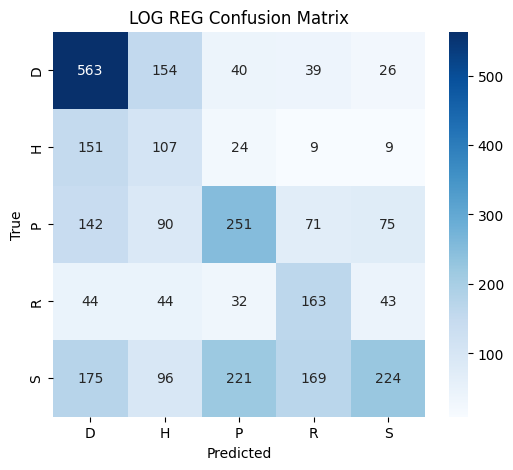

Support vector machine accuracy score = 0.5141796083727211
Support vector machine classification report 
               precision    recall  f1-score   support

           D       0.57      0.73      0.64       822
           H       0.30      0.36      0.33       300
           P       0.49      0.43      0.46       629
           R       0.40      0.59      0.48       326
           S       0.68      0.39      0.50       885

    accuracy                           0.51      2962
   macro avg       0.49      0.50      0.48      2962
weighted avg       0.54      0.51      0.51      2962

Support vector machine best parameters found: {'C': 10, 'class_weight': 'balanced', 'gamma': 0.1}
Support vector machine (tuned) best accuracy score = 0.5560432140445645
Support vector machine (tuned) best classification report
               precision    recall  f1-score   support

           D       0.61      0.74      0.67       822
           H       0.35      0.45      0.39       300
           P 

In [ ]:
#Model evaluation

#Logistic regression (PCA)-------------
print("Logistic regression with PCA accuracy score =",accuracy_score(y_test, y_logpred_pca))
print("Logistic regression with PCA classification report \n", classification_report(y_test, y_logpred_pca))

cm = confusion_matrix(y_test, y_logpred_pca, labels=logcsf_pca.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=logcsf_pca.classes_, yticklabels=logcsf_pca.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LOG REG (PCA) Confusion Matrix')
plt.show()
#----------

#Logistic regression-----------------
print("Logistic regression accuracy score =", accuracy_score(y_test, y_logpred))
print("Logistic regression classification report \n", classification_report(y_test, y_logpred))

cm = confusion_matrix(y_test, y_logpred, labels=logcsf.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=logcsf.classes_, yticklabels=logcsf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('LOG REG Confusion Matrix')
plt.show()
#-------------

#Support vector machine---------------------
print("Support vector machine accuracy score =", accuracy_score(y_test, y_svmpred))
print("Support vector machine classification report \n", classification_report(y_test, y_svmpred))
#----------------------------------------

#Random forest
print("Random forest best accuracy score =", accuracy_score(y_test, y_rfpred))
print("Random forest classification report\n", classification_report(y_test, y_rfpred))

#-------------------